In [1]:
import cartopy.crs as ccrs
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneGroupOut, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, ConfusionMatrixDisplay

## Data Processing

In [2]:
def format_rbg_string(rgbstring):
    """Transform a RGB string to a tuple of floats that matplotlib can understand"""
    rgbs = rgbstring.split(' ')
    rgbtup = tuple(float(rgb) for rgb in rgbs)
    return rgbtup

with open('./data/legend of biomes.txt', 'r') as f:
    lines = [ l.strip() for l in f.readlines()] # Remove endline characters and spaces
    
biome_names = lines[slice(0, len(lines), 2)] # Only use the biome names, not the colors
biome_names = [ ' '.join(l.split(' ')[1:]) for l in biome_names ] # Remove number in front of names
biome_rgbs = lines[slice(1, len(lines), 2)] # Filter out biome RGB colors
biome_rgbs = [format_rbg_string(rgbstr) for rgbstr in biome_rgbs]

biome_names

['Boreal decid forest',
 'Boreal ever forest',
 'Temp/boreal mix fo.',
 'Temp conifer forest',
 'Temp decid forest',
 'Temp broad ever fo.',
 'Temp mixed forest',
 'Trop season forest',
 'Trop rain forest',
 'Trop decid forest',
 'Moist savannas',
 'Dry savannas',
 'Tall grassland',
 'Dry grassland',
 'Xeric wood/shrub',
 'Arid shrub/steppe',
 'Desert',
 'Arctic/alpine tundra']

In [3]:
df_countries = pd.read_csv('./data/gridlist_pan_gfed_ISO3_UN_ecoregion.txt', sep='\\s+')
df_countries.head()

,Lon,Lat,GFED-region,Pan_2007,ISO3,UN,Ecoregion
0,-69.75,-55.25,5,Americas,CHL,152,4
1,-69.25,-55.25,5,Americas,CHL,152,4
2,-71.25,-54.75,5,Americas,CHL,152,4
3,-70.75,-54.75,5,Americas,CHL,152,4
4,-70.25,-54.75,5,Americas,CHL,152,4


/Users/xray/miniforge3/envs/bern01/lib/python3.14/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/xray/miniforge3/envs/bern01/lib/python3.14/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


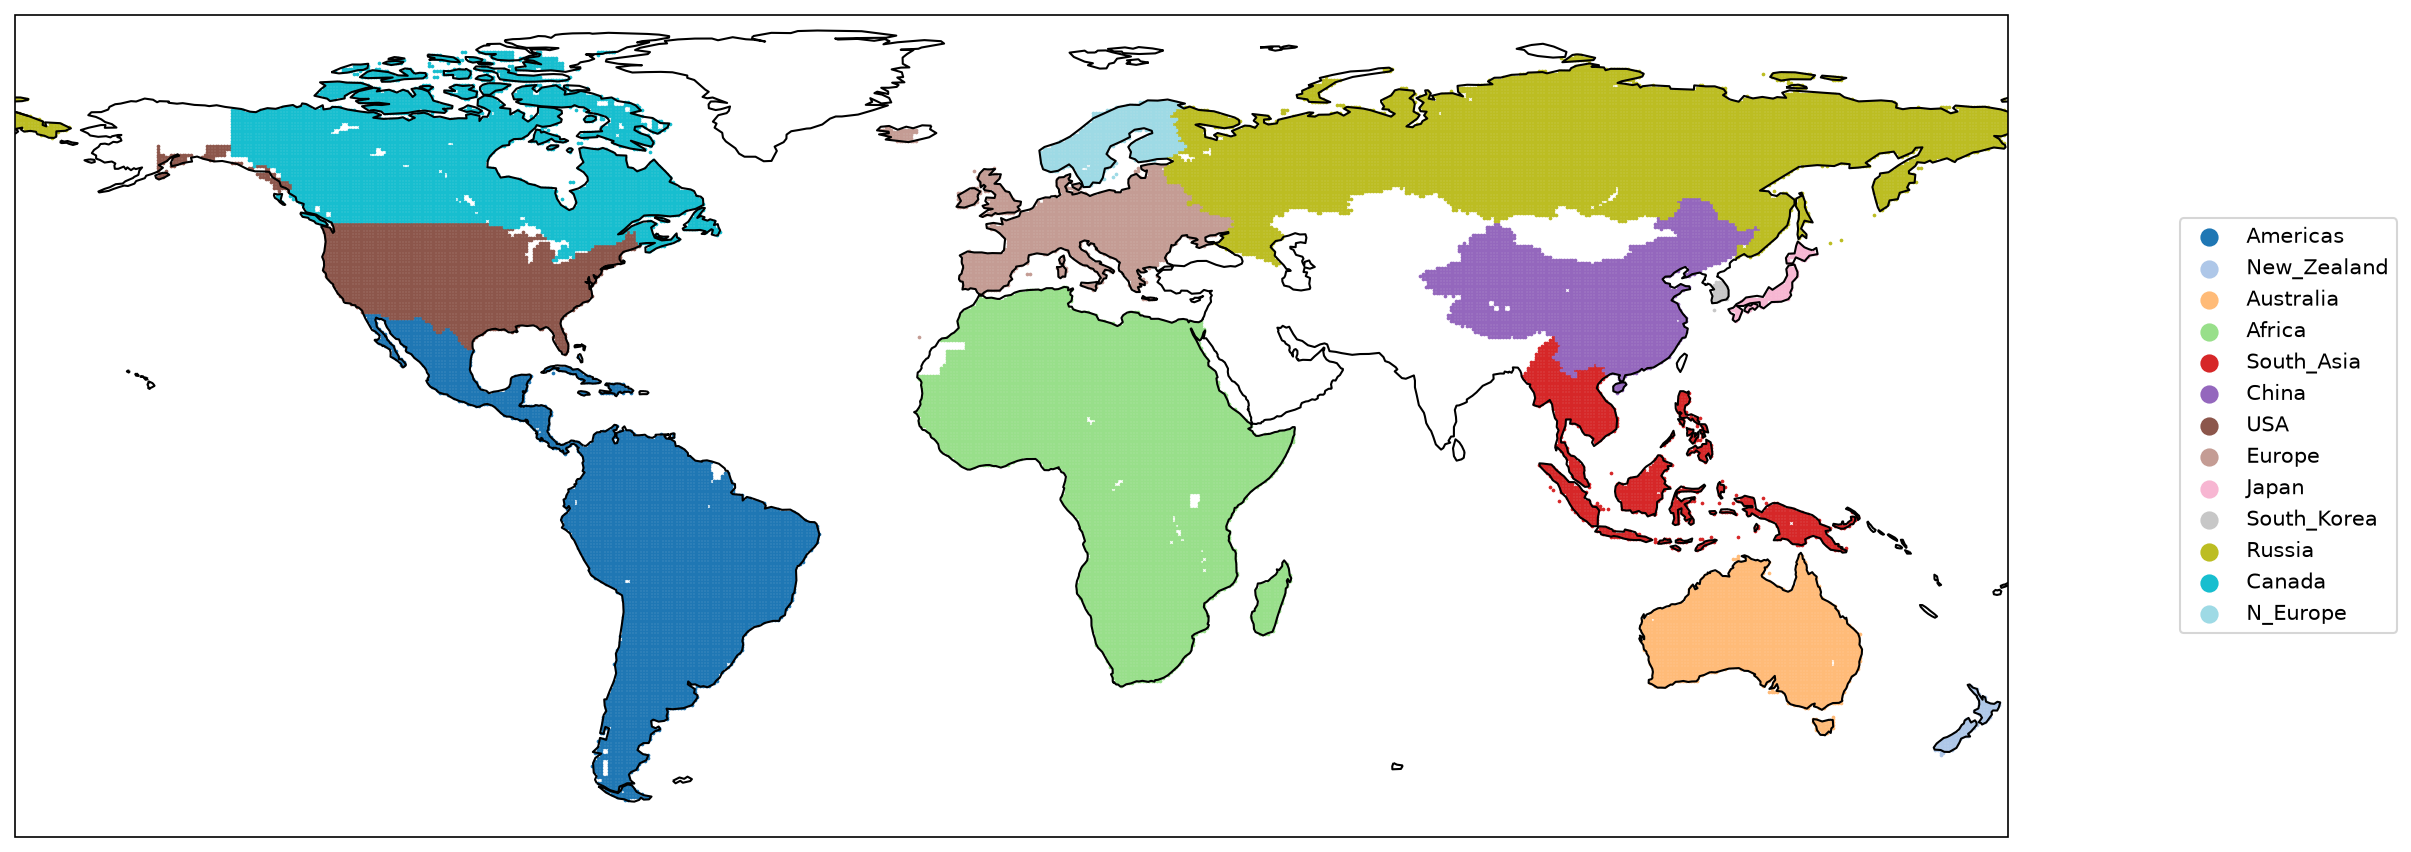

In [29]:
proj = ccrs.PlateCarree()
fig, ax = plt.subplots(figsize=(16, 8), dpi=150, subplot_kw={"projection":proj})

countries = df_countries["Pan_2007"].unique()
colors = plt.cm.tab20(np.linspace(0, 1, len(countries)))

for i, name in enumerate(countries):
    country = df_countries[df_countries["Pan_2007"] == name]
    ax.scatter(country["Lon"], country["Lat"], color=colors[i], s=0.6, label=name, transform=proj)

ax.legend(markerscale=10, loc='center right', bbox_to_anchor=(1.20, 0.5)) # Make markers bigger
ax.coastlines()  # type: ignore
plt.tight_layout()
plt.show()

In [5]:
region_mapping = {
    "Russia": "Russia",

    "Africa": "Africa",

    "Americas": "Latin_Americas",

    "Canada": "North_Americas",
    "USA": "North_Americas",

    "Australia": "Oceania",
    "New_Zealand": "Oceania",

    "Europe": "Europe",
    "N_Europe": "Europe",

    "South_Asia": "South_Asia",

    "Japan": "East_Asia",
    "South_Korea": "East_Asia",
    "China": "East_Asia"
}

df_countries["Region"] = (
    df_countries["Pan_2007"]
    .map(region_mapping)
)

df_countries["Region"].value_counts()

Region
Russia            11696
Africa            10164
North_Americas     9953
Latin_Americas     7176
East_Asia          3980
Europe             3229
Oceania            2961
South_Asia         1691
Name: count, dtype: int64

In [6]:
df_lpj = pd.read_csv('./data/LPJ-GUESS_output_BERN1.csv')
df_lpj.head()

,Lon,Lat,NPP,SoilR,MaxBiomeCmax,MaxBiomeLAI,VegC,LitterC,SoilC,Biome_Cmax,Biome_LAI,Biome_obs
0,39.75,-1.25,0.429,0.390,0.449,1.9821,1.225,0.758,5.941,8,12,12
1,150.25,-34.25,0.554,0.451,6.883,3.3174,6.953,3.221,10.566,7,7,6
2,-63.75,82.75,0.000,0.000,0.000,0.0000,0.000,0.003,0.002,13,13,17
3,59.25,30.75,0.043,0.042,0.090,0.2146,0.127,0.084,0.543,7,11,14
4,24.25,27.75,0.000,0.000,0.000,0.0000,0.000,0.000,0.000,13,13,17


In [7]:
biome_data = df_lpj[["Lon", "Lat", "Biome_obs"]]
biome_data["Biome_obs"].value_counts()

Biome_obs
2     11118
17     6505
9      5924
18     5725
16     4577
14     3965
5      3962
12     3643
15     3134
6      2748
8      2560
10     1702
1      1383
11     1027
3       734
13      367
7       117
Name: count, dtype: int64

/Users/xray/miniforge3/envs/bern01/lib/python3.14/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/xray/miniforge3/envs/bern01/lib/python3.14/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


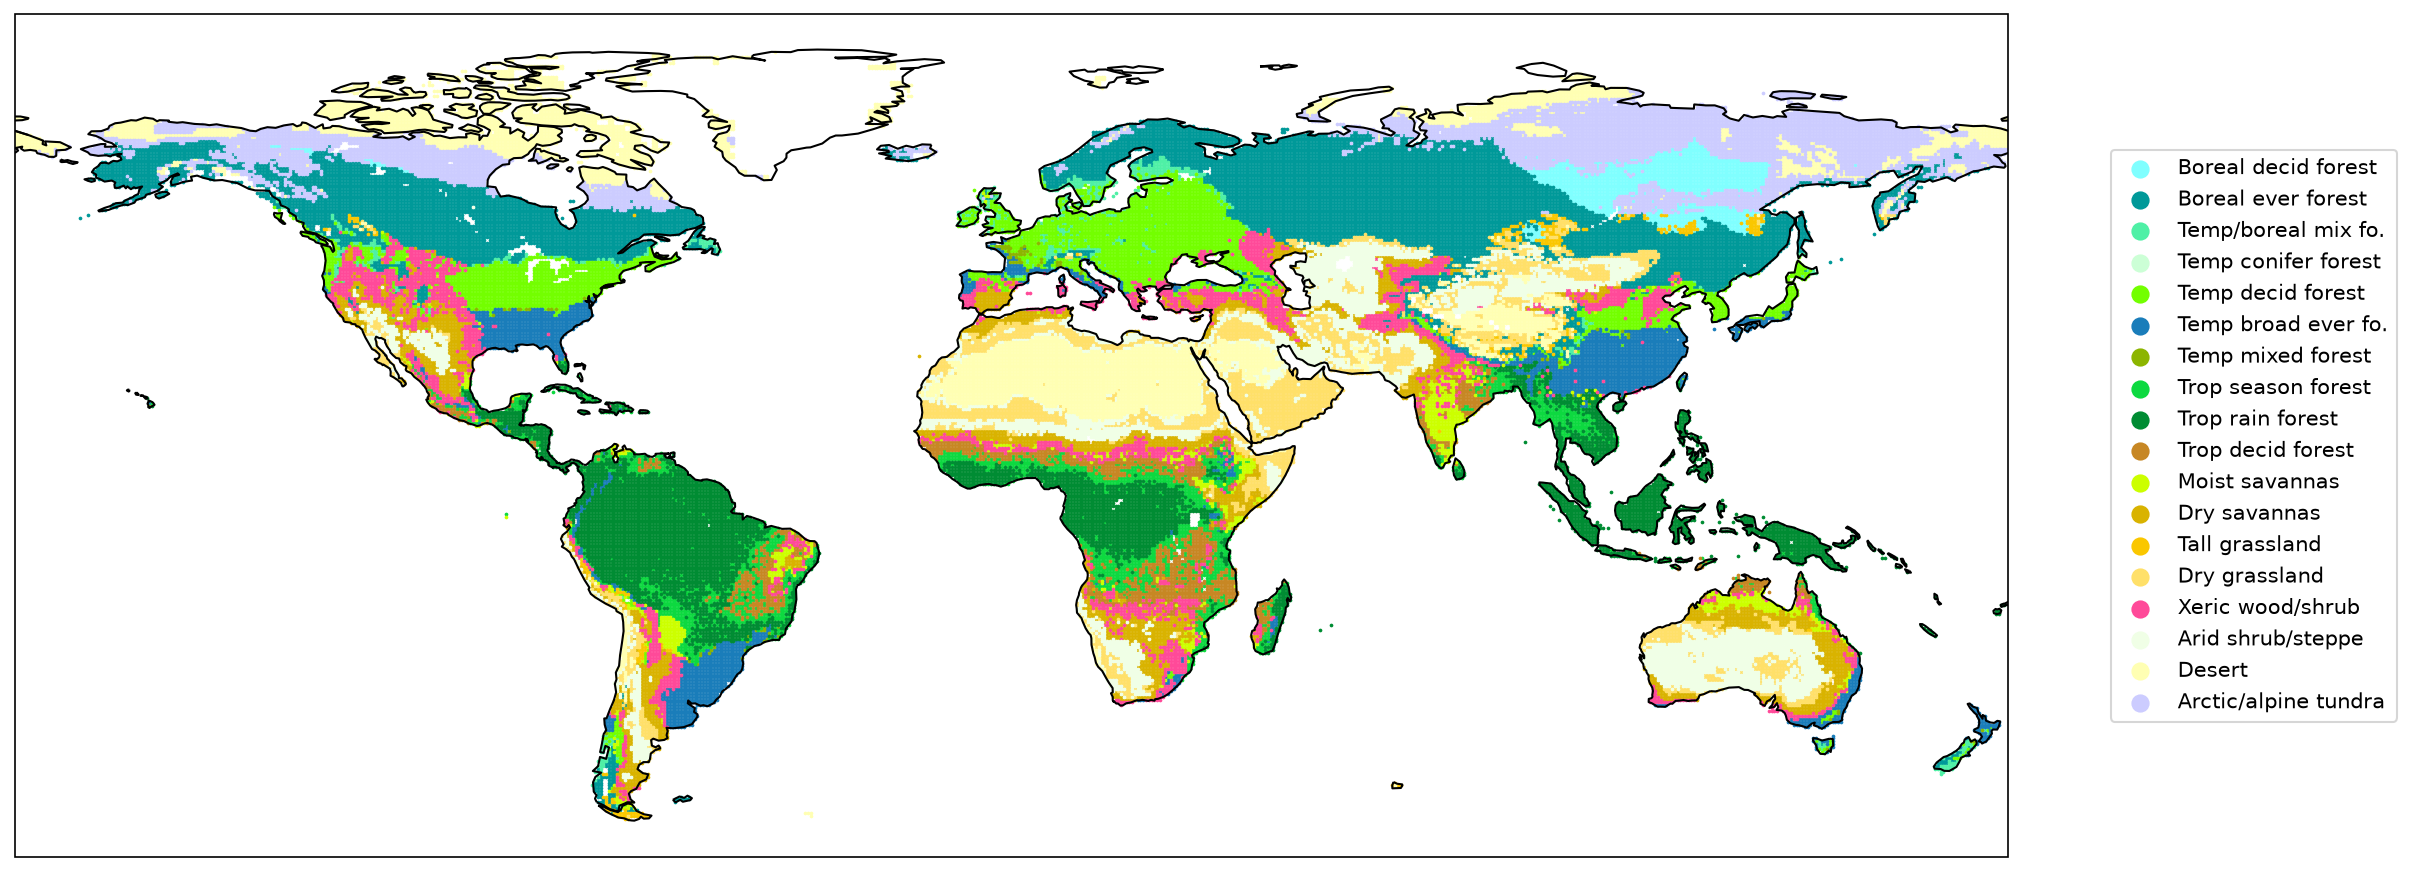

In [8]:
fig, ax = plt.subplots(figsize=(16, 8), dpi=150, subplot_kw={"projection":proj})

# Hacky way of creating a map, pretent it is a scatterplot with lons and lats on x and y!
for i, name in enumerate(biome_names):
    biome = biome_data[biome_data['Biome_obs'] == i + 1]
    biome.plot(x='Lon', y='Lat', color=biome_rgbs[i], ax=ax, kind='scatter', s=0.6, label=name, marker='o')

ax.legend(markerscale=10, loc='center right', bbox_to_anchor=(1.20, 0.5)) # Make markers bigger
ax.coastlines()  # type: ignore
plt.tight_layout()
plt.show()

In [9]:
file_dir = "./data/"
df_P = pd.read_csv(file_dir + "Predaymean1961_1990_stats.csv")
df_T_max = pd.read_csv(file_dir + "Tmaxdaymean1961_1990_stats.csv")
df_T_min = pd.read_csv(file_dir + "Tmindaymean1961_1990_stats.csv")
df_T_mean = pd.read_csv(file_dir + "Tmpdaymean1961_1990_stats.csv")
df_radiation = pd.read_csv(file_dir + "Tswrfdaymean1961_1990_stats.csv")
df_soil = pd.read_csv(file_dir + "soilmap.dat", sep=r"\s+")

In [10]:
df_soil.rename(columns={
    "lon": "Lon",
    "lat": "Lat",
}, inplace=True)

df_soil.head()

,Lon,Lat,clay,silt,sand,orgC,CN,pH,cellfraction
0,-179.75,71.25,0.08,0.37,0.55,0.020,11.0,5.9,0.482
1,-179.75,68.75,0.20,0.48,0.32,0.031,17.0,6.3,0.753
2,-179.75,68.25,0.20,0.48,0.32,0.031,17.0,6.3,0.447
3,-179.75,67.75,0.20,0.48,0.32,0.031,17.0,6.3,0.526
4,-179.75,67.25,0.20,0.48,0.32,0.031,17.0,6.3,0.422


## Data Analysis

In [11]:
dfs = [
    df_lpj,
    df_P,
    df_T_max,
    df_T_min,
    df_T_min,
    df_radiation,
    df_soil,
    df_countries
]

for df in dfs:
    print(df.shape)

(59191, 12)
(59191, 14)
(59191, 14)
(59191, 14)
(59191, 14)
(59191, 14)
(59191, 9)
(50850, 8)


In [12]:
for df in dfs:
    print(df[["Lon", "Lat"]].duplicated().sum())

0
0
0
0
0
0
0
0


In [13]:
coords = (
    df_lpj[["Lon", "Lat"]]
    .sort_values(["Lon", "Lat"])
    .reset_index(drop=True)
)

for df in dfs[1:]:
    others = (
        df[["Lon", "Lat"]]
        .sort_values(["Lon", "Lat"])
        .reset_index(drop=True)
    )
    print(coords.equals(others))

True
True
True
True
True
True
False


## Data Transformations

In [42]:
group_countries = df_countries[
    ["Lon", "Lat", "Region"]
]
feat_P = df_P[
    ["Lon", "Lat", "SpringMean", "SummerMean", "FallMean", "WinterMean"]
].rename(columns={
    "SpringMean": "P_SpringMean", 
    "SummerMean": "P_SummerMean", 
    "FallMean": "P_FallMean", 
    "WinterMean": "P_WinterMean"
})
feat_T_max = df_T_max[
    ["Lon", "Lat", "SpringMean", "SummerMean", "FallMean", "WinterMean"]
].rename(columns={
    "SpringMean": "T_max_SpringMean", 
    "SummerMean": "T_max_SummerMean", 
    "FallMean": "T_max_FallMean", 
    "WinterMean": "T_max_WinterMean"
})
feat_T_min = df_T_min[
    ["Lon", "Lat", "SpringMean", "SummerMean", "FallMean", "WinterMean"]
].rename(columns={
    "SpringMean": "T_min_SpringMean", 
    "SummerMean": "T_min_SummerMean", 
    "FallMean": "T_min_FallMean", 
    "WinterMean": "T_min_WinterMean"
})
feat_T_mean = df_T_mean[
    ["Lon", "Lat", "SpringMean", "SummerMean", "FallMean", "WinterMean"]
].rename(columns={
    "SpringMean": "T_mean_SpringMean", 
    "SummerMean": "T_mean_SummerMean", 
    "FallMean": "T_mean_FallMean", 
    "WinterMean": "T_mean_WinterMean"
})
feat_soil = df_soil[["Lon", "Lat", "clay", "silt", "sand", "orgC", "CN", "pH", "cellfraction"]]
targe_lpj = df_lpj[["Lon", "Lat", "NPP", "VegC", "Biome_Cmax", "Biome_LAI", "Biome_obs"]]

In [43]:
df_data = (
    group_countries
    .merge(feat_P, on=["Lat", "Lon"])
    .merge(feat_T_max, on=["Lat", "Lon"])
    .merge(feat_T_min, on=["Lat", "Lon"])
    .merge(feat_T_mean, on=["Lat", "Lon"])
    .merge(feat_soil, on=["Lat", "Lon"])
    .merge(targe_lpj, on=["Lat", "Lon"])
)
df_data.head()

,Lon,Lat,Region,P_SpringMean,P_SummerMean,P_FallMean,P_WinterMean,T_max_SpringMean,T_max_SummerMean,T_max_FallMean,...,sand,orgC,CN,pH,cellfraction,NPP,VegC,Biome_Cmax,Biome_LAI,Biome_obs
0,-69.75,-55.25,Latin_Americas,3.2789,3.0611,2.5611,2.6605,282.91,278.98,277.80,...,0.43,0.014,11.0,7.6,0.339,0.646,0.719,11,11,13
1,-69.25,-55.25,Latin_Americas,2.8966,2.7385,2.2631,2.3146,282.69,278.49,277.35,...,0.43,0.014,11.0,7.6,0.340,0.654,0.724,11,11,13
2,-71.25,-54.75,Latin_Americas,4.7026,4.3444,3.7831,4.0549,283.24,279.17,277.95,...,0.43,0.014,11.0,7.6,0.339,0.715,0.831,11,11,13
3,-70.75,-54.75,Latin_Americas,3.8305,3.6034,3.0523,3.2355,282.81,278.63,277.39,...,0.43,0.014,11.0,7.6,0.340,0.682,0.768,11,11,13
4,-70.25,-54.75,Latin_Americas,3.2060,3.0229,2.5071,2.6362,281.96,277.55,276.29,...,0.43,0.014,11.0,7.6,0.340,0.583,0.644,11,11,13


## Biome Classification

### Binary Classification

Biome Selected: 9 Trop rain forest

Latin_Americas -> Africa

In [44]:
df_bin = df_data.copy()
df_bin["Biome_rainforest"] = np.where(df_bin["Biome_obs"] == 9, 0, 1)
df_bin.head()

,Lon,Lat,Region,P_SpringMean,P_SummerMean,P_FallMean,P_WinterMean,T_max_SpringMean,T_max_SummerMean,T_max_FallMean,...,orgC,CN,pH,cellfraction,NPP,VegC,Biome_Cmax,Biome_LAI,Biome_obs,Biome_rainforest
0,-69.75,-55.25,Latin_Americas,3.2789,3.0611,2.5611,2.6605,282.91,278.98,277.80,...,0.014,11.0,7.6,0.339,0.646,0.719,11,11,13,1
1,-69.25,-55.25,Latin_Americas,2.8966,2.7385,2.2631,2.3146,282.69,278.49,277.35,...,0.014,11.0,7.6,0.340,0.654,0.724,11,11,13,1
2,-71.25,-54.75,Latin_Americas,4.7026,4.3444,3.7831,4.0549,283.24,279.17,277.95,...,0.014,11.0,7.6,0.339,0.715,0.831,11,11,13,1
3,-70.75,-54.75,Latin_Americas,3.8305,3.6034,3.0523,3.2355,282.81,278.63,277.39,...,0.014,11.0,7.6,0.340,0.682,0.768,11,11,13,1
4,-70.25,-54.75,Latin_Americas,3.2060,3.0229,2.5071,2.6362,281.96,277.55,276.29,...,0.014,11.0,7.6,0.340,0.583,0.644,11,11,13,1


In [45]:
pd.crosstab(
    df_bin["Region"],
    df_bin["Biome_rainforest"],
    normalize="index"
)

Biome_rainforest,0,1
Region,,
Africa,0.136560,0.863440
East_Asia,0.004020,0.995980
Europe,0.000000,1.000000
Latin_Americas,0.420987,0.579013
North_Americas,0.001407,0.998593
Oceania,0.002026,0.997974
Russia,0.000000,1.000000
South_Asia,0.785334,0.214666


In [46]:
test_data = df_bin[df_bin["Region"] == "Africa"].copy()
training_data = df_bin[df_bin["Region"] == "Latin_Americas"].copy()
test_data.head()

,Lon,Lat,Region,P_SpringMean,P_SummerMean,P_FallMean,P_WinterMean,T_max_SpringMean,T_max_SummerMean,T_max_FallMean,...,orgC,CN,pH,cellfraction,NPP,VegC,Biome_Cmax,Biome_LAI,Biome_obs,Biome_rainforest
1119,19.75,-34.75,Africa,0.86558,1.8170,1.7515,0.92565,295.77,291.78,289.70,...,0.004,17.0,5.6,0.534,0.259,2.181,7,7,15,1
1190,18.75,-34.25,Africa,0.94340,3.0982,3.1399,1.22640,296.85,292.27,290.00,...,0.004,17.0,5.6,0.355,0.283,2.381,7,7,15,1
1191,19.25,-34.25,Africa,0.99762,2.8038,3.0070,1.29660,296.36,291.54,289.15,...,0.008,10.0,6.4,0.334,0.302,2.754,7,7,15,1
1192,19.75,-34.25,Africa,0.99017,1.9425,2.1412,1.09640,296.09,291.02,288.67,...,0.008,10.0,6.4,0.333,0.287,2.495,7,7,15,1
1193,20.25,-34.25,Africa,1.34150,1.6976,1.6829,1.24690,296.73,290.92,288.66,...,0.008,10.0,6.4,0.308,0.280,2.478,7,7,15,1


In [48]:
feature_cols = [
    "P_SpringMean", "P_SummerMean", "P_FallMean", "P_WinterMean", 
    "T_max_SpringMean", "T_max_SummerMean", "T_max_FallMean", "T_max_WinterMean", 
    "T_min_SpringMean", "T_min_SummerMean", "T_min_FallMean", "T_min_WinterMean",
    "T_mean_SpringMean", "T_mean_SummerMean", "T_mean_FallMean", "T_mean_WinterMean", 
    "clay", "silt", "sand", "orgC", "CN", "pH", "cellfraction"
]

X = training_data[feature_cols]
y = training_data["Biome_rainforest"]
groups = training_data["Region"]

In [ ]:
rfc = RandomForestClassifier(
    random_state=7,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [200, 500],
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [1, 5],
    "max_features": ["sqrt", None],
    "class_weight": ["balanced"]
}

grid_search = GridSearchCV(
    estimator=rfc,
    param_grid=param_grid,
    scoring="f1_macro",
    n_jobs=-1,
    return_train_score=True
)

grid_search.fit(
    X,
    y
)

/Users/xray/miniforge3/envs/bern01/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/xray/miniforge3/envs/bern01/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/xray/miniforge3/envs/bern01/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/xray/miniforge3/envs/bern01/li

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...andom_state=7)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': ['balanced'], 'max_depth': [None, 10, ...], 'max_features': ['sqrt', None], 'min_samples_leaf': [1, 5], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- 

In [54]:
print(grid_search.best_params_)
print(grid_search.best_score_)

best_model = grid_search.best_estimator_

{'class_weight': 'balanced', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 200}
0.7853419156692482


In [55]:
X_test = test_data[feature_cols]
y_test = test_data["Biome_rainforest"]

y_pred = best_model.predict(X_test)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["rainforest", "non_rainforest"]
    )
)

                precision    recall  f1-score   support

    rainforest       0.78      0.89      0.83      1388
non_rainforest       0.98      0.96      0.97      8776

      accuracy                           0.95     10164
     macro avg       0.88      0.93      0.90     10164
  weighted avg       0.95      0.95      0.95     10164



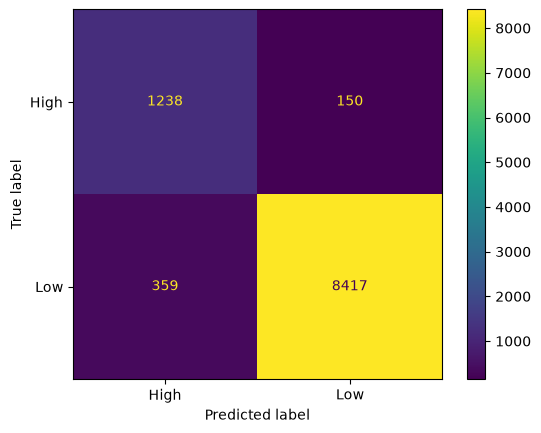

In [56]:
ConfusionMatrixDisplay.from_estimator(
    best_model, X_test, y_test, display_labels=['High', 'Low'], 
)
plt.show()

#### LPJ-GUESS performance

In [60]:
y_pred_LAI = (test_data["Biome_LAI"] == 9).astype("Int64")
y_pred_Cmax = (test_data["Biome_Cmax"] == 9).astype("Int64")

print(
    classification_report(
        y_test,
        y_pred_Cmax,
        target_names=["rainforest", "non_rainforest"]
    )
)

                precision    recall  f1-score   support

    rainforest       0.14      1.00      0.24      1388
non_rainforest       1.00      0.00      0.01      8776

      accuracy                           0.14     10164
     macro avg       0.57      0.50      0.12     10164
  weighted avg       0.88      0.14      0.04     10164



### Multiclass Classification

## Regression

### NPP Regression

### VegC Regression